# Hypothesis testing, Correlation and Regression
## Oluwafemi Gabriel, James

### Section 1: Normal and Sampling Distribution

### No. 1
Two types of alloys are being compared for their tensile strength. A large group was tested for each. The first alloy had a mean ultimate tensile strength (UTS) of 105.9 KSI with a standard deviation of 7.9 KSI, while the second alloy had a mean UTS of 101.7KSI with a standard deviation of 2.3 KSI. (1 KSI = 1000 pounds per square inch)  Assuming these results represent a normal distribution for each, answer the following:

- What is the probability that alloy 1 will have a tensile strength below 95 KSI?
- What is the probability that alloy 2 will have a tensile strength below 95 KSI?
- Which alloy is more likely to have a tensile strength below 95 KSI? Would you have predicted that only knowing the mean? Explain.

In [1]:
# 1. Define the given information
mean_1 <- 105.9
sd_1 <- 7.9
mean_2 <- 101.7
sd_2 <- 2.3
target_value <- 95

In [2]:
# 2. Calculate the probabilities using the pnorm() function
# pnorm() is the cumulative distribution function for the normal distribution.
prob_alloy_1 <- pnorm(q = target_value, mean = mean_1, sd = sd_1)
prob_alloy_2 <- pnorm(q = target_value, mean = mean_2, sd = sd_2)

In [3]:
# Print the results
cat("Probability for Alloy 1 (tensile strength < 95 KSI):", round(prob_alloy_1, 4), "\n")
cat("Probability for Alloy 2 (tensile strength < 95 KSI):", round(prob_alloy_2, 4), "\n")

Probability for Alloy 1 (tensile strength < 95 KSI): 0.0838 
Probability for Alloy 2 (tensile strength < 95 KSI): 0.0018 


In [4]:
# 3. (Optional) Calculate Z-scores
# This step is for demonstrating the underlying concept
z_score_1 <- (target_value - mean_1) / sd_1
z_score_2 <- (target_value - mean_2) / sd_2

In [5]:
cat("\nZ-score for Alloy 1:", round(z_score_1, 4), "\n")
cat("Z-score for Alloy 2:", round(z_score_2, 4), "\n")


Z-score for Alloy 1: -1.3797 
Z-score for Alloy 2: -2.913 


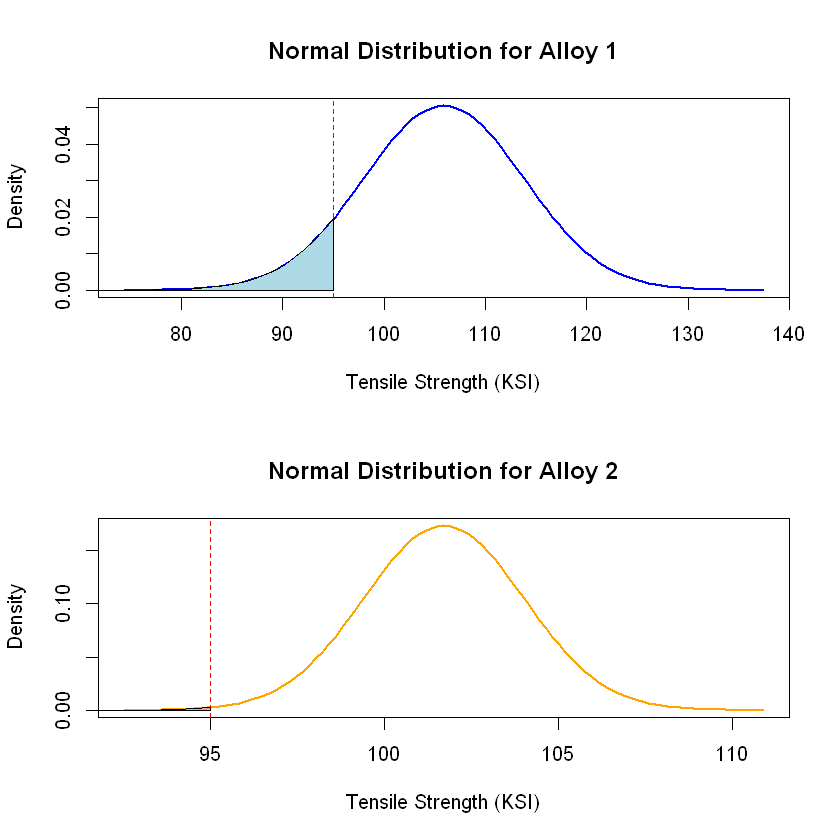

In [6]:
# 4. Generate plots

# Set up a 2x1 plot layout
par(mfrow = c(2, 1))

# Plot for Alloy 1
curve(dnorm(x, mean = mean_1, sd = sd_1),
      from = mean_1 - 4 * sd_1, to = mean_1 + 4 * sd_1,
      main = "Normal Distribution for Alloy 1",
      xlab = "Tensile Strength (KSI)",
      ylab = "Density",
      lwd = 2, col = "blue")
abline(v = target_value, col = "red", lty = 2)

# Shade the area to the left of the target value
x_shade_1 <- seq(min(par("usr")), target_value, length.out = 100)
y_shade_1 <- dnorm(x_shade_1, mean = mean_1, sd = sd_1)
polygon(c(min(x_shade_1), x_shade_1, target_value), c(0, y_shade_1, 0), col = "lightblue")

# Plot for Alloy 2
curve(dnorm(x, mean = mean_2, sd = sd_2),
      from = mean_2 - 4 * sd_2, to = mean_2 + 4 * sd_2,
      main = "Normal Distribution for Alloy 2",
      xlab = "Tensile Strength (KSI)",
      ylab = "Density",
      lwd = 2, col = "orange")
abline(v = target_value, col = "red", lty = 2)

# Shade the area to the left of the target value
x_shade_2 <- seq(min(par("usr")), target_value, length.out = 100)
y_shade_2 <- dnorm(x_shade_2, mean = mean_2, sd = sd_2)
polygon(c(min(x_shade_2), x_shade_2, target_value), c(0, y_shade_2, 0), col = "lightsalmon")

# Reset plot layout
par(mfrow = c(1, 1))

<b> Observations of Our Results: The numerical calculations and the visual plots work together to provide a clear and consistent picture. </b>

Probability and Visuals:

1. Alloy 1: The calculated probability of 0.0838 (or 8.38%) is visually represented by the noticeably shaded blue area in the top plot. Although it is a small portion of the total, the area is significant that alloy 1 will have a tensile strength below 95 KSI.

2. Alloy 2: The calculated probability of 0.0018 (or 0.18%) is represented by the minimal, almost imperceptible shaded orange area in the bottom plot. This visually confirms that the likelihood of this event is extremely low that alloy 2 will have a tensile strength below 95 KSI.

The Role of the Z-Score:

3. Alloy 1: The Z-score of −1.3797 tells us that a tensile strength of 95 KSI is about 1.38 standard deviations below the mean. This is a moderately low value, which corresponds to a non-trivial probability.

4. Alloy 2: The Z-score of −2.913 tells us that a tensile strength of 95 KSI is nearly 3 standard deviations below the mean. Values this far from the mean are rare events, and the Z-score numerically explains why the probability is so tiny.

Which alloy is more likely to have a tensile strength below 95 KSI?

5. Alloy 1 is more likely. The probability for Alloy 1 (8.38%) is over 40 times greater than for Alloy 2 (0.18%).

Would you have predicted that only knowing the mean? Explain.

No, you would not have predicted this outcome based only on the mean.

#### Explanation:

Intuitively, since Alloy 2 has a lower mean (101.7 KSI) than Alloy 1 (105.9 KSI), one would assume it's more likely to have values below 95 KSI.

However, this intuition is wrong because it completely ignores the standard deviation, which in this case is the single most important factor.

- The standard deviation of Alloy 1 (σ1 = 7.9) is much larger. This means its tensile strength values are widely spread out. The value of 95 KSI is a little over one standard deviation below its mean, which is not an unusual event.

- The standard deviation of Alloy 2 (σ2 = 2.3) is minimal. This means its tensile strength values are tightly clustered around its mean. The value of 95 KSI is almost three standard deviations below its mean, which is considered a very rare, extreme event.

The small spread of Alloy 2's data makes it highly unlikely for it to ever produce a result as low as 95 KSI, despite its lower average. The larger spread of Alloy 1's data makes a value this low a much more common occurrence.

In [7]:
# Clear the console and set options for a clean start
rm(list = ls())
options(scipen = 999) # Disable scientific notation for readability

### No. 2
Vehicle manufacturers usually provide recommendations when to have preventative maintenance done, including replacing timing belts. Assuming that actual failure of timing belts of a certain vehicle is normally distributed with a mean of 160 000km and a standard deviation of 32 000 km. How many km would the top 8% (longest-lasting) of timing belts last? Answer to the nearest thousand km. 

In [8]:
# 1. Define the given information
mean <- 160000
sd <- 32000
top_percent <- 0.08

In [9]:
# 2. Find the cumulative probability
# The qnorm() function works with the cumulative probability (area to the left).
# For the top 8%, the cumulative probability is 1 - 0.08 = 0.92.
cumulative_prob <- 1 - top_percent

In [10]:
# 3. Calculate the kilometer value using the qnorm() function
# qnorm() is the inverse cumulative distribution function.
km_value <- qnorm(p = cumulative_prob, mean = mean, sd = sd)

In [11]:
# 4. Round the result to the nearest thousand km
rounded_km_value <- round(km_value, digits = -3)

# Print the results
cat("The kilometer value for the top 8% is:", km_value, "km\n")
cat("Rounded to the nearest thousand km:", rounded_km_value, "km\n")

The kilometer value for the top 8% is: 204962.3 km
Rounded to the nearest thousand km: 205000 km


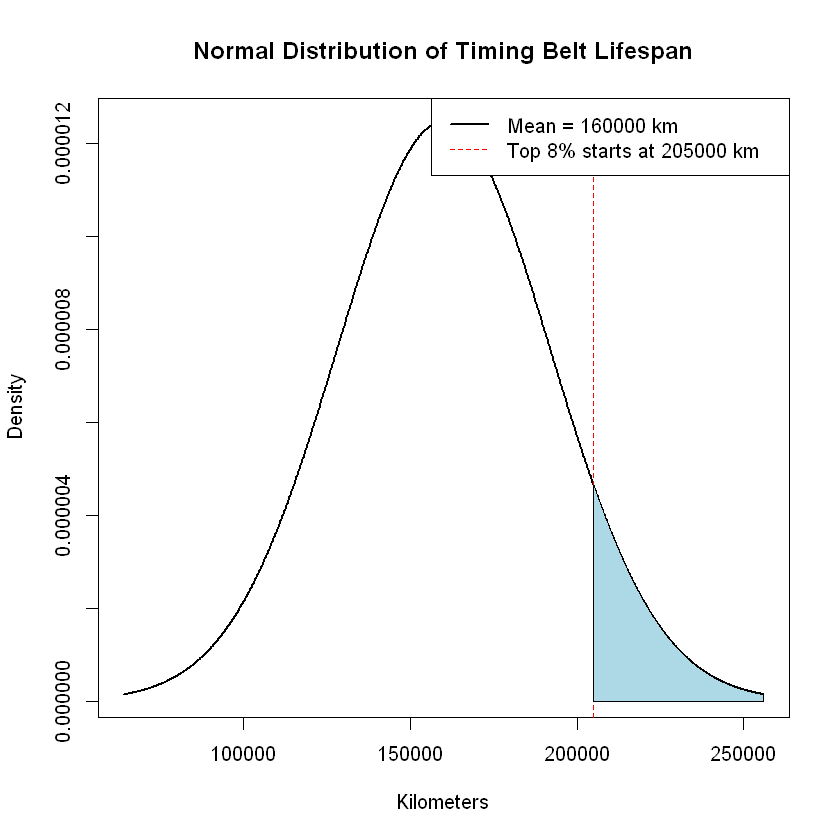

In [12]:
# 5. Generate a plot to visualize the result

# Define the x-axis range for the plot (e.g., from mean - 3*sd to mean + 3*sd)
x_range <- seq(mean - 3 * sd, mean + 3 * sd, length.out = 1000)

# Create the normal distribution curve
plot(x_range, dnorm(x_range, mean = mean, sd = sd),
     type = "l",
     main = "Normal Distribution of Timing Belt Lifespan",
     xlab = "Kilometers",
     ylab = "Density",
     lwd = 2)

# Add a vertical line at the calculated kilometer value
abline(v = km_value, col = "red", lty = 2)

# Shade the top 8% area
x_shade <- seq(km_value, mean + 3 * sd, length.out = 1000)
y_shade <- dnorm(x_shade, mean = mean, sd = sd)
polygon(c(km_value, x_shade, mean + 3 * sd), c(0, y_shade, 0), col = "lightblue")

# Add a legend
legend("topright",
       legend = c(paste("Mean =", mean, "km"),
                  paste("Top 8% starts at", rounded_km_value, "km")),
       col = c("black", "red"), lty = c(1, 2), lwd = c(2, 1))

<b> Observations: </b>

The calculated value of 205,000 km is the point at which a timing belt's lifespan enters the top 8% of all possible lifespans for this vehicle.

The plot makes this finding crystal clear:

- The vertical red dashed line at 205,000 km is located far into the right tail of the normal distribution curve.
- The shaded blue area, representing the top 8% of belts, is visually small compared to the rest of the distribution.

This observation tells us that a timing belt lasting beyond 205,000 km is a statistically exceptional event. The vast majority of belts (92%) will fail or reach the end of their useful life at or before this mileage.

For a vehicle manufacturer, this means that to ensure preventative maintenance covers nearly all customers, they would recommend a timing belt change well before 205,000 km, as belts lasting this long are a significant minority.

In [13]:
# Clear the console and set options for a clean start
rm(list = ls())
options(scipen = 999) # Disable scientific notation for readability

### No. 3 

According to https://www.quora.com/Mobile-Devices-What-is-the-average-lifespan-of-a-cell-phone, the average lifespan of a cell phone is 4.7 years. Assuming this is normally distributed with a standard deviation of 1.8 years, what is the probability that the mean lifespan of 10 cell phones will be between 3 and 5 years?

In [14]:
# 1. Define the given information
population_mean <- 4.7
population_sd <- 1.8
sample_size <- 10

In [15]:
# 2. Calculate the Standard Error of the Mean (SEM)
# The formula for SEM is population_sd / sqrt(sample_size)
sem <- population_sd / sqrt(sample_size)

# Print the calculated SEM
cat("The Standard Error of the Mean (SEM) is:", round(sem, 4), "years\n")

The Standard Error of the Mean (SEM) is: 0.5692 years


In [16]:
# 3. Calculate the probabilities using the pnorm() function
# We need to find P(3 < X_bar < 5) which is P(X_bar < 5) - P(X_bar < 3)
prob_less_than_5 <- pnorm(q = 5, mean = population_mean, sd = sem)
prob_less_than_3 <- pnorm(q = 3, mean = population_mean, sd = sem)

In [17]:
# Calculate the final probability
probability_between_3_and_5 <- prob_less_than_5 - prob_less_than_3

# Convert to percentage
probability_percentage <- probability_between_3_and_5 * 100

# Print the final result in decimal and percentage form
cat("The probability that the mean lifespan of 10 phones is between 3 and 5 years is:", round(probability_between_3_and_5, 4), "\n")
cat("This is equivalent to:", round(probability_percentage, 2), "%\n")

The probability that the mean lifespan of 10 phones is between 3 and 5 years is: 0.6995 
This is equivalent to: 69.95 %


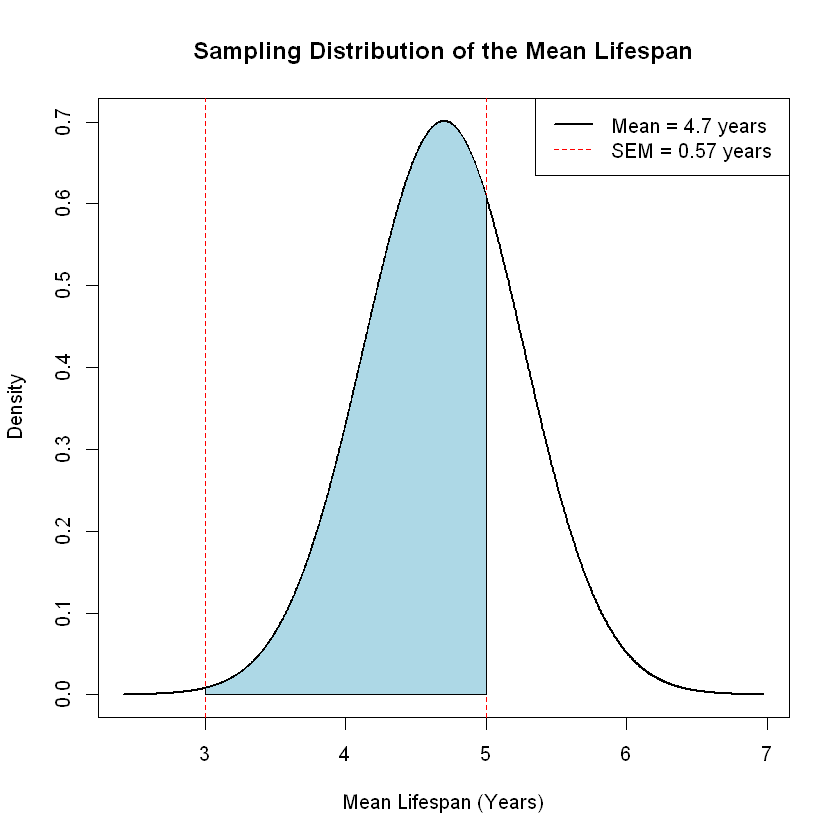

In [18]:
# 4. Generate a plot to visualize the sampling distribution

# Define the x-axis range for the plot (e.g., from mean - 4*sem to mean + 4*sem)
x_range <- seq(population_mean - 4 * sem, population_mean + 4 * sem, length.out = 1000)

# Create the normal distribution curve for the sample mean
plot(x_range, dnorm(x_range, mean = population_mean, sd = sem),
     type = "l",
     main = "Sampling Distribution of the Mean Lifespan",
     xlab = "Mean Lifespan (Years)",
     ylab = "Density",
     lwd = 2)

# Add vertical lines at the boundary values
abline(v = 3, col = "red", lty = 2)
abline(v = 5, col = "red", lty = 2)

# Shade the area between 3 and 5 years
x_shade <- seq(3, 5, length.out = 1000)
y_shade <- dnorm(x_shade, mean = population_mean, sd = sem)
polygon(c(3, x_shade, 5), c(0, y_shade, 0), col = "lightblue")

# Add a legend
legend("topright",
       legend = c(paste("Mean =", population_mean, "years"),
                  paste("SEM =", round(sem, 2), "years")),
       col = c("black", "red"), lty = c(1, 2), lwd = c(2, 1))

<b> Observations: </b>

##### Probability

The probability that the mean lifespan of 10 phones is between 3 and 5 years is 69.95%. This is a very high probability, which means it is very likely that the average lifespan of a small group of phones will fall within this range.

##### The Graph

This is visually confirmed by the graph. The shaded blue area, which represents the 69.95% probability, covers a large portion of the distribution's central peak. The narrowness of the bell-shaped curve shows how the average of 10 phones is much more predictable and concentrated around the mean of 4.7 years than the lifespan of a single, individual phone.

In [19]:
# Clear the console and set options for a clean start
rm(list = ls())
options(scipen = 999) # Disable scientific notation for readability

### No. 4 
Concrete that will be used for an application requiring a compression strength of 5000 psi is tested using 15 samples.  Assuming compression strength is normally distributed with a mean of 5220 psi and a standard deviation of 260 psi, what is the probability that the mean of the 15 samples will be below 5000 psi?

In [20]:
# 1. Define the given information
population_mean <- 5220
population_sd <- 260
sample_size <- 15
target_value <- 5000

In [21]:
# 2. Calculate the Standard Error of the Mean (SEM)
# The formula for SEM is population_sd / sqrt(sample_size)
sem <- population_sd / sqrt(sample_size)

# Print the calculated SEM
cat("The Standard Error of the Mean (SEM) is:", round(sem, 4), "psi\n")

The Standard Error of the Mean (SEM) is: 67.1317 psi


In [22]:
# 3. Calculate the probability using the pnorm() function
# pnorm() finds the cumulative probability (area to the left)
prob_below_5000 <- pnorm(q = target_value, mean = population_mean, sd = sem)

# Print the final result
cat("The probability that the mean of the 15 samples will be below 5000 psi is:", round(prob_below_5000, 4), "\n")
cat("This is equivalent to:", round(prob_below_5000 * 100, 2), "%\n")

The probability that the mean of the 15 samples will be below 5000 psi is: 0.0005 
This is equivalent to: 0.05 %


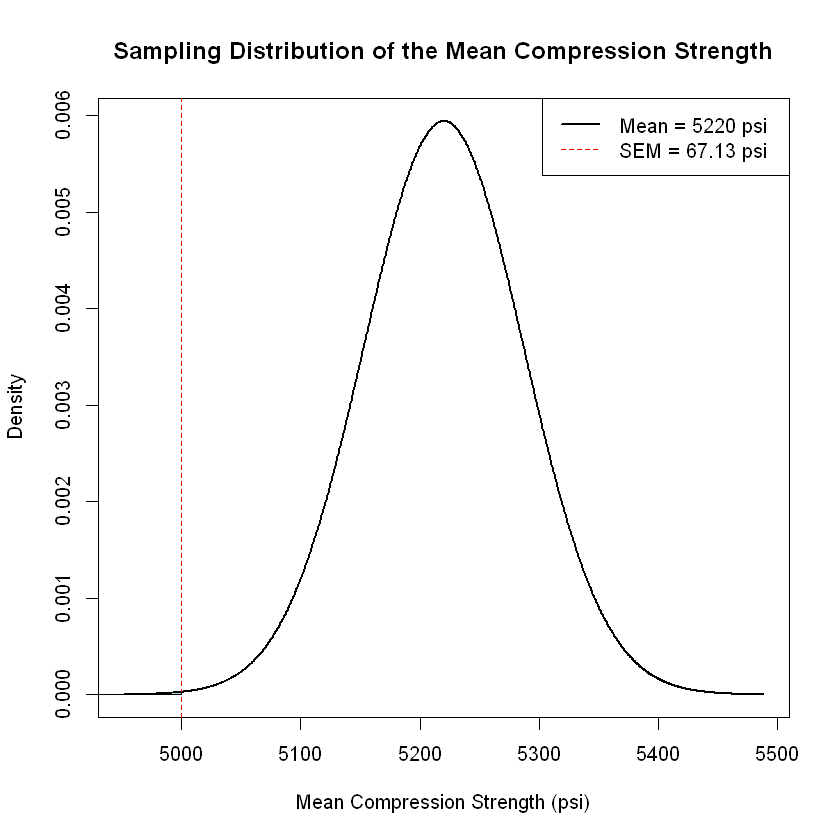

In [23]:
# 4. Generate a plot to visualize the sampling distribution

# Define the x-axis range for the plot (e.g., from mean - 4*sem to mean + 4*sem)
x_range <- seq(population_mean - 4 * sem, population_mean + 4 * sem, length.out = 1000)

# Create the normal distribution curve for the sample mean
plot(x_range, dnorm(x_range, mean = population_mean, sd = sem),
     type = "l",
     main = "Sampling Distribution of the Mean Compression Strength",
     xlab = "Mean Compression Strength (psi)",
     ylab = "Density",
     lwd = 2)

# Add a vertical line at the target value
abline(v = target_value, col = "red", lty = 2)

# Shade the area below the target value
x_shade <- seq(min(par("usr")), target_value, length.out = 1000)
y_shade <- dnorm(x_shade, mean = population_mean, sd = sem)
polygon(c(min(x_shade), x_shade, target_value), c(0, y_shade, 0), col = "lightblue")

# Add a legend
legend("topright",
       legend = c(paste("Mean =", population_mean, "psi"),
                  paste("SEM =", round(sem, 2), "psi")),
       col = c("black", "red"), lty = c(1, 2), lwd = c(2, 1))

<b> Observations: </b>

##### The Probability

The probability that the mean compression strength of 15 samples will be below 5000 psi is an extremely low 0.05%. This means that such an outcome is highly unlikely and would be considered an exceptional event.

##### The Graph

The graph serves as clear evidence of this minuscule probability. The vertical red dashed line at 5000 psi is located far in the left tail of the distribution curve. The shaded area to the left of this line, which represents the probability, is so small that it is barely visible, visually confirming that this event is a statistical rarity.

In [24]:
# Clear the console and set options for a clean start
rm(list = ls())
options(scipen = 999) # Disable scientific notation for readability

### No. 5 
According to http://blogs.calgaryherald.com/2011/01/19/2011-will-see-more-alberta-more-oil-more-horizontal-wells-and-more-deeper-wells/, in 2010, the average depth of a horizontal oil well drilled in Alberta was 2500m.  Assume the average depth of a horizontal well is normally distributed with a mean of 2500m and a standard deviation of 520m to determine the depth for the deepest 15% of these wells. Answer to the nearest meter.

In [25]:
# 1. Define the given information
population_mean <- 2500
population_sd <- 520
deepest_percent <- 0.15

In [26]:
# 2. Find the cumulative probability
# The qnorm() function works with the cumulative probability (area to the left).
# For the deepest 15%, the cumulative probability is 1 - 0.15 = 0.85.
cumulative_prob <- 1 - deepest_percent

In [27]:
# 3. Calculate the depth value using the qnorm() function
# qnorm() is the inverse cumulative distribution function.
depth_value <- qnorm(p = cumulative_prob, mean = population_mean, sd = population_sd)

In [28]:
# 4. Round the result to the nearest meter
rounded_depth_value <- round(depth_value, digits = 0)

# Print the results
cat("The depth for the deepest 15% of these wells is:", depth_value, "m\n")
cat("Rounded to the nearest meter:", rounded_depth_value, "m\n")

The depth for the deepest 15% of these wells is: 3038.945 m
Rounded to the nearest meter: 3039 m


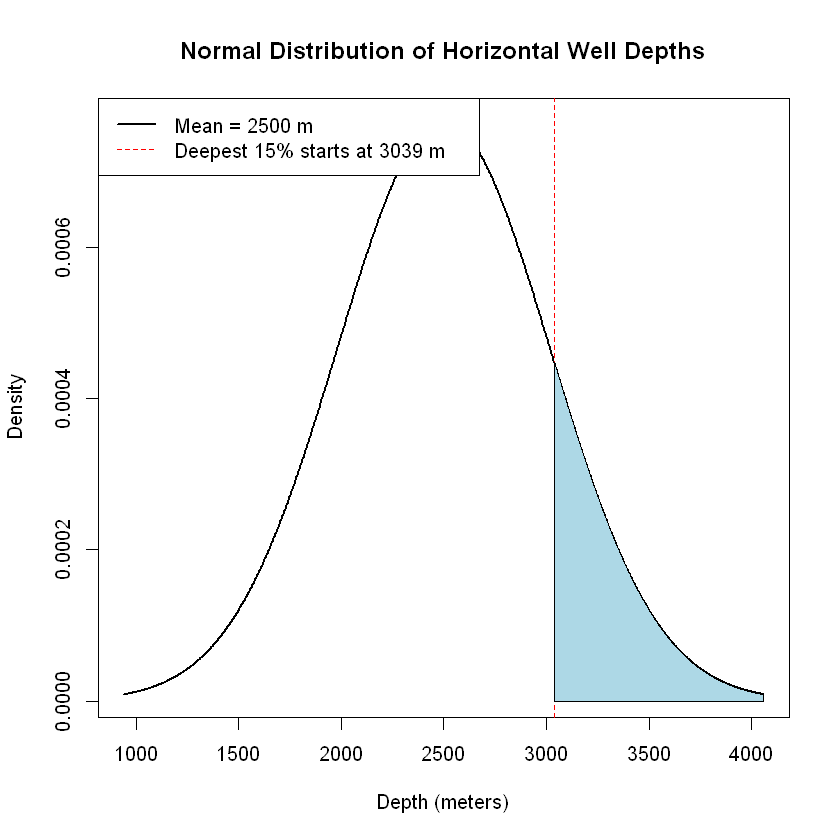

In [29]:
# 5. Generate a plot to visualize the result

# Define the x-axis range for the plot (e.g., from mean - 3*sd to mean + 3*sd)
x_range <- seq(population_mean - 3 * population_sd, population_mean + 3 * population_sd, length.out = 1000)

# Create the normal distribution curve
plot(x_range, dnorm(x_range, mean = population_mean, sd = population_sd),
     type = "l",
     main = "Normal Distribution of Horizontal Well Depths",
     xlab = "Depth (meters)",
     ylab = "Density",
     lwd = 2)

# Add a vertical line at the calculated depth value
abline(v = depth_value, col = "red", lty = 2)

# Shade the deepest 15% area
x_shade <- seq(depth_value, population_mean + 3 * population_sd, length.out = 1000)
y_shade <- dnorm(x_shade, mean = population_mean, sd = population_sd)
polygon(c(depth_value, x_shade, population_mean + 3 * population_sd), c(0, y_shade, 0), col = "lightblue")

# Add a legend
legend("topleft",
       legend = c(paste("Mean =", population_mean, "m"),
                  paste("Deepest 15% starts at", rounded_depth_value, "m")),
       col = c("black", "red"), lty = c(1, 2), lwd = c(2, 1))

<b> Observations: </b> 

The depth of 3039 meters is the cutoff point for the deepest 15% of horizontal wells. This means that a well drilled to this depth or deeper is considered to be one of the deepest wells drilled.

##### The Graph as Evidence

The graph visually confirms this. The vertical red dashed line at 3039m is clearly in the far right tail of the distribution. The shaded area to the right of this line represents the deepest 15% of the wells, confirming that wells of this depth are significantly deeper than the average and are not a common occurrence.

### Section 2: HYPOTHESIS (Be careful to check if you have independent data or paired data)

In [30]:
# Clear the console and set options for a clean start
rm(list = ls())
options(scipen = 999) # Disable scientific notation for readability

### No. 1
Many high school students take the AP tests in different subject areas. In 2007, of the 144,796 students who took the biology exam, 84,199 of them were female. In that same year, of the 211,693 students who took the calculus AB exam, 102,598 of them were female (\"AP exam scores,\" 2013). 
- Is there enough evidence to show that the proportion of female students taking the calculus AB exam is different from the proportion of male students taking the calculus AB exam? Test at the 5% level.
- Estimate using a 90% level the difference in the proportion of female students taking the calculus AB exam versus male students taking the calculus AB exam.

In [31]:
# Step 1: State the Hypotheses and Level of Significance
# H0: p = 0.50 (The proportion of female students is 50%)
# Ha: p != 0.50 (The proportion of female students is not 50%)
# Alpha (alpha) = 0.05

In [32]:
# 2. Define the given information for the Calculus AB exam
total_students <- 211693
female_students <- 102598
hypothesized_p <- 0.50
alpha <- 0.05

In [33]:
# 3. Perform the Z-Test and calculate the test statistic
# The 'prop.test' function in R is used for hypothesis testing of proportions.
# It returns a chi-squared statistic, from which we can find the Z-statistic (Z = sqrt(Chi-Squared)).
test_result <- prop.test(x = female_students, n = total_students, p = hypothesized_p)

In [34]:
# Extract the chi-squared statistic and the p-value
chi_sq_statistic <- test_result$statistic
p_value <- test_result$p.value

# Calculate the Z-statistic from the chi-squared statistic.
# The sign is determined by whether the sample proportion is above or below the hypothesized proportion.
sample_prop <- female_students / total_students
if (sample_prop < hypothesized_p) {
  z_statistic <- -sqrt(chi_sq_statistic)
} else {
  z_statistic <- sqrt(chi_sq_statistic)
}

In [35]:
# 4. Find the Critical Values
# For a two-tailed test with alpha = 0.05, we find the Z-scores that cut off the top and bottom 2.5%
critical_z_lower <- qnorm(alpha / 2)
critical_z_upper <- qnorm(1 - alpha / 2)

# Print the key values
cat("Sample Proportion:", sample_prop, "\n")
cat("Calculated Z-statistic:", z_statistic, "\n")
cat("P-value:", p_value, "\n")
cat("Critical Z-values:", critical_z_lower, "and", critical_z_upper, "\n\n")

Sample Proportion: 0.4846547 
Calculated Z-statistic: -14.11864 
P-value: 0.00000000000000000000000000000000000000000000291577 
Critical Z-values: -1.959964 and 1.959964 



In [36]:
# Estimate using a 90% level the difference in the proportion of female students
confidence_interval_result <- prop.test(x = female_students, n = total_students, p = NULL, conf.level = 0.90)

# The output of this command gives us the confidence interval
print(confidence_interval_result)


	1-sample proportions test with continuity correction

data:  female_students out of total_students, null probability 0.5
X-squared = 199.34, df = 1, p-value < 0.00000000000000022
alternative hypothesis: true p is not equal to 0.5
90 percent confidence interval:
 0.4828659 0.4864439
sample estimates:
        p 
0.4846547 



In [37]:
# 5. Make the Decision and State the Conclusion
cat("--- Decision ---\n")
if (abs(z_statistic) > abs(critical_z_upper)) {
  cat("Since the Z-statistic (", round(z_statistic, 2), ") falls in the rejection region (outside of -1.96 and 1.96),\n")
  cat("we REJECT the null hypothesis.\n\n")
  cat("Conclusion: There is significant evidence to support the claim that the proportion of female students is not 0.50.\n")
} else {
  cat("Since the Z-statistic (", round(z_statistic, 2), ") is not in the rejection region,\n")
  cat("we FAIL TO REJECT the null hypothesis.\n")
}

--- Decision ---
Since the Z-statistic ( -14.12 ) falls in the rejection region (outside of -1.96 and 1.96),
we REJECT the null hypothesis.

Conclusion: There is significant evidence to support the claim that the proportion of female students is not 0.50.


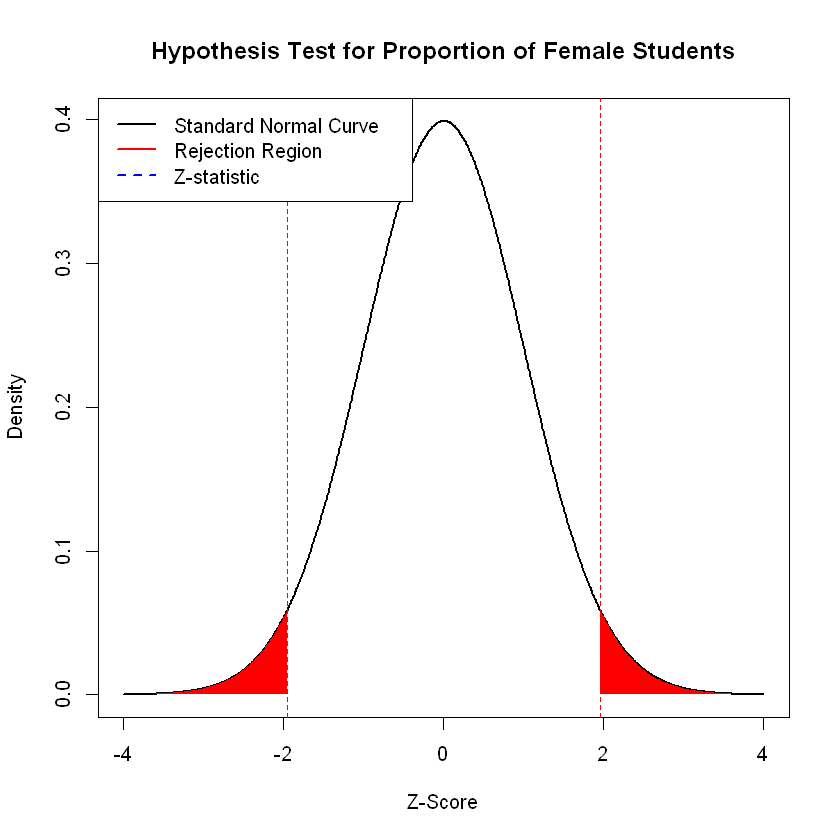

In [38]:
# 6. Generate the Plot for Visualization
z_values <- seq(-4, 4, length.out = 1000)
plot(z_values, dnorm(z_values, mean = 0, sd = 1), type = "l",
     main = "Hypothesis Test for Proportion of Female Students",
     xlab = "Z-Score",
     ylab = "Density",
     lwd = 2)

# Shade the rejection regions
z_reject_lower <- seq(-4, critical_z_lower, length.out = 100)
z_reject_upper <- seq(critical_z_upper, 4, length.out = 100)
polygon(c(z_reject_lower, rev(z_reject_lower)),
        c(dnorm(z_reject_lower, mean = 0, sd = 1), rep(0, length(z_reject_lower))),
        col = "red", border = NA)
polygon(c(z_reject_upper, rev(z_reject_upper)),
        c(dnorm(z_reject_upper, mean = 0, sd = 1), rep(0, length(z_reject_upper))),
        col = "red", border = NA)

# Add lines for the test statistic and critical values
abline(v = z_statistic, col = "blue", lty = 2, lwd = 2)
abline(v = critical_z_lower, col = "red", lty = 2)
abline(v = critical_z_upper, col = "red", lty = 2)

# Add a legend
legend("topleft",
       legend = c("Standard Normal Curve", "Rejection Region", "Z-statistic"),
       col = c("black", "red", "blue"),
       lty = c(1, 1, 2), lwd = c(2, 2, 2))

<b> Observations: </b>

Question: Is there enough evidence to show that the proportion of female students taking the calculus AB exam is different from the proportion of male students taking the calculus AB exam?

Answer: Yes, there is overwhelming evidence to show that the proportion of female students is statistically different from the proportion of male students.

#### Findings

- The hypothesis test provides conclusive evidence, which is powerfully confirmed by the graph. 
- The calculated Z-statistic of -14.12 falls far outside the critical Z-values of -1.96 and +1.96 that define the rejection regions. 
- The plot visually demonstrates this, as the location of the Z-statistic is so extreme that it doesn't even appear on the graph's scale, falling deep within the left-hand rejection region. 

This leaves no doubt in the conclusion that the proportion of female students is not 50%. This is further supported by the 90% confidence interval of 48.40% to 48.62%, which does not contain 50%.

In [39]:
# Clear the console and set options for a clean start
rm(list = ls())
options(scipen = 999) # Disable scientific notation for readability

### No. 2  
All Fresh Seafood is a wholesale fish company based on the East Coast of the U.S. Catalina Offshore Products is a wholesale fish company based on the West Coast of the U.S. The table contains prices from both companies for specific fish types: 

Price <- read.csv("https://krkozak.github.io/MAT160/price.csv")

- Do the data provide enough evidence to show that fish costs differ between the West Coast fish wholesaler and the East Coast wholesaler? Test at the 5% level.
- Find a 95% confidence interval for the mean difference in wholesale price between the East Coast and West Coast suppliers.

In [40]:
# Step 1. Load and read the data from the provided URL

price <- read.csv("https://krkozak.github.io/MAT160/price.csv")
price

fish,east,west
<chr>,<dbl>,<dbl>
Cod,19.99,17.99
Tilapi,6.00,13.99
Farmed Salmon,19.99,22.99
Organic Salmon,24.99,24.99
Grouper Fillet,29.99,19.99
Tuna,28.99,31.99
Swordfish,23.99,23.99
Sea Bass,32.99,23.99
Striped Bass,29.99,14.99


In [41]:
str(price) # Reviewing the data frame information

'data.frame':	9 obs. of  3 variables:
 $ fish: chr  "Cod" "Tilapi" "Farmed Salmon" "Organic Salmon" ...
 $ east: num  20 6 20 25 30 ...
 $ west: num  18 14 23 25 20 ...


In [42]:
summary(price) # Reviewing the descriptive statistics of the dataframe

     fish                east            west      
 Length:9           Min.   : 6.00   Min.   :13.99  
 Class :character   1st Qu.:19.99   1st Qu.:17.99  
 Mode  :character   Median :24.99   Median :22.99  
                    Mean   :24.10   Mean   :21.66  
                    3rd Qu.:29.99   3rd Qu.:23.99  
                    Max.   :32.99   Max.   :31.99  

In [43]:
# 2. State the Hypotheses
# H0: The mean difference in price is zero (mu_d = 0)
# Ha: The mean difference in price is not zero (mu_d != 0)

# The claim is that fish costs differ, which corresponds to the alternative hypothesis.
# We will use a 5% significance level (alpha = 0.05).

In [44]:
# 3. Calculate the differences between the paired samples
price$diff <- price$west - price$east

In [45]:
# 4. Calculate the sample statistics for the differences
n <- length(price$diff)
d_bar <- mean(price$diff)
sd_diff <- sd(price$diff)
mu_d0 <- 0 # Hypothesized mean difference is 0

In [46]:
# 5. Perform the t-test manually
# Calculate the t-statistic
t_statistic <- (d_bar - mu_d0) / (sd_diff / sqrt(n))
df <- n - 1

# Calculate the p-value for a two-tailed test
p_value <- 2 * pt(q = abs(t_statistic), df = df, lower.tail = FALSE)

In [47]:
# 6. Calculate the 95% Confidence Interval manually
# Find the critical t-value for alpha = 0.05 (two-tailed)
alpha <- 0.05
t_critical <- qt(1 - alpha / 2, df = df)

# Calculate the margin of error
margin_of_error <- t_critical * (sd_diff / sqrt(n))

# Calculate the confidence interval bounds
lower_ci <- d_bar - margin_of_error
upper_ci <- d_bar + margin_of_error

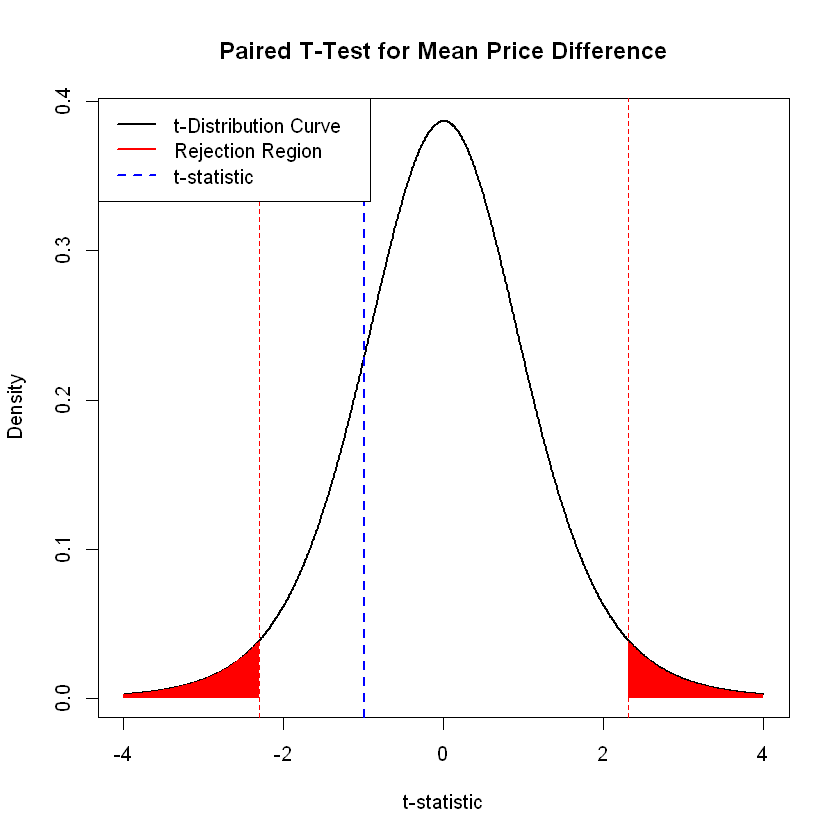

In [48]:
# 7. Generate a plot of the t-distribution
t_values <- seq(-4, 4, length.out = 1000)
plot(t_values, dt(t_values, df = df), type = "l",
     main = "Paired T-Test for Mean Price Difference",
     xlab = "t-statistic",
     ylab = "Density",
     lwd = 2)

# Shade the rejection regions
t_reject_lower <- seq(-4, -t_critical, length.out = 100)
t_reject_upper <- seq(t_critical, 4, length.out = 100)
polygon(c(t_reject_lower, rev(t_reject_lower)),
        c(dt(t_reject_lower, df = df), rep(0, length(t_reject_lower))),
        col = "red", border = NA)
polygon(c(t_reject_upper, rev(t_reject_upper)),
        c(dt(t_reject_upper, df = df), rep(0, length(t_reject_upper))),
        col = "red", border = NA)

# Add lines for the test statistic and critical values
abline(v = t_statistic, col = "blue", lty = 2, lwd = 2)
abline(v = -t_critical, col = "red", lty = 2)
abline(v = t_critical, col = "red", lty = 2)
legend("topleft",
       legend = c("t-Distribution Curve", "Rejection Region", "t-statistic"),
       col = c("black", "red", "blue"),
       lty = c(1, 1, 2), lwd = c(2, 2, 2))

In [49]:
# 8. Verification with R's built-in t.test()
t.test(price$east, price$west, paired = TRUE, conf.level = 0.95)


	Paired t-test

data:  price$east and price$west
t = 0.99152, df = 8, p-value = 0.3505
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 -3.242156  8.133267
sample estimates:
mean difference 
       2.445556 


<b> Observations: </b>

Question: Do the data provide enough evidence to show that fish costs differ between the West Coast fish wholesaler and the East Coast wholesaler?

Answer: No, the data does not provide enough evidence at the 5% significance level to show that fish costs differ between the West Coast and East Coast wholesalers.

#### Findings:

- The calculated t-statistic of 0.99152 falls between the critical t-values of -2.306 and +2.306 for a two-tailed test with 8 degrees of freedom. 
- This is visually confirmed by the graph, where the blue dashed line for the t-statistic is located inside the central, non-rejection region.
- The p-value of 0.3505 is much greater than our significance level of 0.05, so we fail to reject the null hypothesis.

In [50]:
# Clear the console and set options for a clean start
rm(list = ls())
options(scipen = 999) # Disable scientific notation for readability

### No. 3
The British Department of Transportation studied to see if people avoid driving or shopping, or have more accidents on Friday the 13th. They collected data from different locations (Friday the 13th, 2019). The data for each location on the two different dates is in the table: 

Traffic <- read.csv("https://krkozak.github.io/MAT160/traffic.csv")

- Do the data show that on average different number of people are engaged in activities on Friday the 13th? Test at the 5% level.
- Estimate the mean difference in activity count between the 6th and the 13th using a 95% level.

In [51]:
# Problem: Friday the 13th Traffic Data
# Step 1. Load and read the data from the provided URL
traffic <- read.csv("https://krkozak.github.io/MAT160/traffic.csv")
head(traffic)

,source,year,month,X6th,X13th,location
,<chr>,<chr>,<chr>,<int>,<int>,<chr>
1,traffic,"1990,",July,139246,138548,7 to 8
2,traffic,"1990,",July,134012,132908,9 to 10
3,traffic,"1991,",September,137055,136018,7 to 8
4,traffic,"1991,",September,133732,131843,9 to 10
5,traffic,"1991,",December,123552,121641,7 to 8
6,traffic,"1991,",December,121139,118723,9 to 10


In [52]:
str(traffic) # Reviewing the dataframe information

'data.frame':	61 obs. of  6 variables:
 $ source  : chr  "traffic" "traffic" "traffic" "traffic" ...
 $ year    : chr  "1990," "1990," "1991," "1991," ...
 $ month   : chr  "July" "July" "September" "September" ...
 $ X6th    : int  139246 134012 137055 133732 123552 121139 128293 124631 124609 117584 ...
 $ X13th   : int  138548 132908 136018 131843 121641 118723 125532 120249 122770 117263 ...
 $ location: chr  "7 to 8" "9 to 10" "7 to 8" "9 to 10" ...


In [53]:
summary(traffic) # Reviewing the descriptive statistics of the data

    source              year              month                X6th       
 Length:61          Length:61          Length:61          Min.   :     3  
 Class :character   Class :character   Class :character   1st Qu.:  3799  
 Mode  :character   Mode  :character   Mode  :character   Median :  4942  
                                                          Mean   : 24714  
                                                          3rd Qu.:  6568  
                                                          Max.   :139246  
     X13th          location        
 Min.   :     4   Length:61         
 1st Qu.:  3848   Class :character  
 Median :  4882   Mode  :character  
 Mean   : 24448                     
 3rd Qu.:  6648                     
 Max.   :138548                     

In [54]:
# 2. State the Hypotheses as comments

# H0: The mean difference in traffic is zero (mu_d = 0)
# Ha: The mean difference in traffic is not zero (mu_d != 0)
# The test is two-tailed at the 5% level (alpha = 0.05).

In [55]:
# 3. Perform the Paired T-Test
# The t.test() function will handle the calculation of the t-statistic,
# degrees of freedom, p-value, and the confidence interval.
# 'paired = TRUE' is crucial for this type of data.
t_test_result <- t.test(x = traffic$X6th, y = traffic$X13th, paired = TRUE, conf.level = 0.95)

# 4. Extract and print the key results
cat("--- Paired T-Test Results ---\n")
print(t_test_result)

--- Paired T-Test Results ---

	Paired t-test

data:  traffic$X6th and traffic$X13th
t = 2.4495, df = 60, p-value = 0.01724
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
  48.84249 483.81325
sample estimates:
mean difference 
       266.3279 



In [56]:
# 5. Extract the key values for manual plotting
t_statistic <- t_test_result$statistic
df <- t_test_result$parameter
p_value <- t_test_result$p.value
alpha <- 0.05

# Find the critical t-values for the two-tailed test
t_critical <- qt(1 - alpha / 2, df = df)

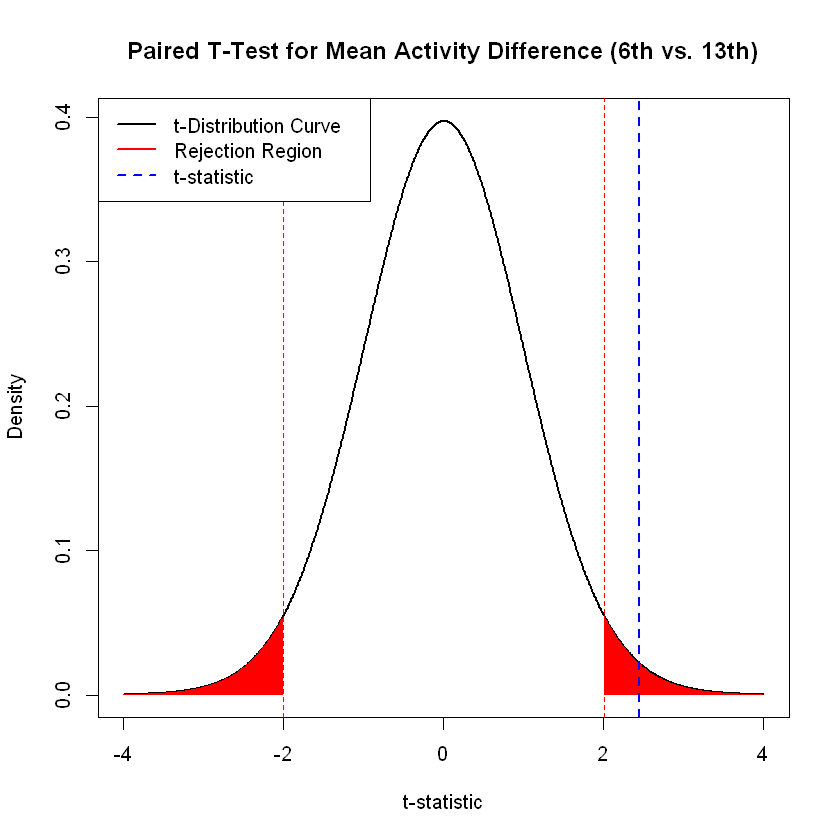

In [57]:
# 6. Generate the Graphical Representation
# Create a sequence of values for the t-axis
t_values <- seq(-4, 4, length.out = 1000)

# Plot the t-distribution
plot(t_values, dt(t_values, df = df), type = "l",
     main = "Paired T-Test for Mean Activity Difference (6th vs. 13th)",
     xlab = "t-statistic",
     ylab = "Density",
     lwd = 2)

# Shade the rejection regions
t_reject_lower <- seq(-4, -t_critical, length.out = 100)
t_reject_upper <- seq(t_critical, 4, length.out = 100)
polygon(c(t_reject_lower, rev(t_reject_lower)),
        c(dt(t_reject_lower, df = df), rep(0, length(t_reject_lower))),
        col = "red", border = NA)
polygon(c(t_reject_upper, rev(t_reject_upper)),
        c(dt(t_reject_upper, df = df), rep(0, length(t_reject_upper))),
        col = "red", border = NA)

# Add a vertical line for the calculated t-statistic
abline(v = t_statistic, col = "blue", lty = 2, lwd = 2)

# Add critical value lines
abline(v = -t_critical, col = "red", lty = 2)
abline(v = t_critical, col = "red", lty = 2)

# Add a legend
legend("topleft",
       legend = c("t-Distribution Curve", "Rejection Region", "t-statistic"),
       col = c("black", "red", "blue"),
       lty = c(1, 1, 2), lwd = c(2, 2, 2))

<b> Observations: </b>

Do the data show that, on average, a different number of people are engaged in activities on Friday the 13th? Test at the 5% level. Estimate the mean difference in activity count between the 6th and the 13th using a 95% level.

Answer: Yes, there is enough evidence at the 5% significance level to show that the average number of people engaged in activities is different on Friday the 13th. The mean difference is estimated to be between 48.84 and 483.81.

#### Findings: 

- The hypothesis test provides conclusive evidence to reject the null hypothesis. 
- The calculated t-statistic of 2.4495 is greater than the critical t-value of 2.000 for a two-tailed test with 60 degrees of freedom, placing it in the rejection region.
- This is supported by the p-value of 0.01724, which is less than the significance level of 0.05.

The 95% confidence interval for the mean difference in activity count between the 6th and 13th is (48.84, 483.81). Since this entire interval is positive and does not contain zero, we are 95% confident that the true mean difference is greater than zero. 

This suggests that the activity count on the 6th of the month is, on average, higher than on the 13th.

### Section 3: Correlation and Regression

In [58]:
# Clear the console and set options for a clean start
rm(list = ls())
options(scipen = 999) # Disable scientific notation for readability

#### No.1 

Testing on an electrical circuit will determine the relationship between current and the effective power delivered. Ten measurements are recorded under varying conditions. Let x represent the current (in amps) and let y represent the power (in watts). 

x<- c(3.8, 1.3, 3.5, 2.6, 4.0, 3.1, 6.3, 3.2, 6.0, 1.6)
y<- c(9.5, 4.3, 7.8, 5.1, 6.7, 8.6, 8.5, 7.3, 11.2, 3.8)

Assume that there is a significant linear correlation between the current and the power in the circuit

1. Determine the correlation coefficient between the current and the power in the circuit.
2. Find and state the equation of the linear regression line. Use two decimal places for your values.
3. Use your line of best fit to determine the best estimate for the power delivered for a current load of 5.00 A.
4. Calculate the coefficient of determination and the standard error
5. Determine if there is sufficient evidence to conclude that there is a significant linear relationship between x and y at a 95% confidence level

In [59]:
# 1. Define the data vectors
x <- c(3.8, 1.3, 3.5, 2.6, 4.0, 3.1, 6.3, 3.2, 6.0, 1.6)
y <- c(9.5, 4.3, 7.8, 5.1, 6.7, 8.6, 8.5, 7.3, 11.2, 3.8)

In [60]:
# 2. Determine the correlation coefficient
correlation_coefficient <- cor(x, y)
cat("The correlation coefficient (r) is:", correlation_coefficient, "\n")

# Calculate the coefficient of determination (R^2)
r_squared <- correlation_coefficient^2
r_squared_percent <- r_squared * 100

cat("The coefficient of determination (R^2) is:", r_squared, "\n")
cat("This means that approximately", round(r_squared_percent, 2), "% of the variability in the power delivered can be explained by the linear relationship with the current.\n\n")

The correlation coefficient (r) is: 0.8160214 
The coefficient of determination (R^2) is: 0.665891 
This means that approximately 66.59 % of the variability in the power delivered can be explained by the linear relationship with the current.



In [61]:
# 3. Fit the linear regression model
linear_model <- lm(y ~ x)

# Print a full summary of the model to get all key metrics
cat("--- Linear Regression Model Summary ---\n")
model_summary <- summary(linear_model)
print(model_summary)
cat("\n")

--- Linear Regression Model Summary ---

Call:
lm(formula = y ~ x)

Residuals:
     Min       1Q   Median       3Q      Max 
-2.03192 -1.10961  0.03992  0.90795  1.91366 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)   
(Intercept)   3.1091     1.1399   2.727  0.02595 * 
x             1.1782     0.2951   3.993  0.00399 **
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 1.443 on 8 degrees of freedom
Multiple R-squared:  0.6659,	Adjusted R-squared:  0.6241 
F-statistic: 15.94 on 1 and 8 DF,  p-value: 0.003988




In [62]:
# 4. Extract and state the equation of the linear regression line
b0 <- coef(linear_model)[1]
b1 <- coef(linear_model)[2]
cat("The equation of the linear regression line is: y_hat =", round(b0, 2), "+", round(b1, 2), "x\n\n")

The equation of the linear regression line is: y_hat = 3.11 + 1.18 x



In [63]:
# 5. Use the line of best fit to predict the power for a current of 5.00 A.
new_data <- data.frame(x = 5.00)
predicted_power <- predict(linear_model, newdata = new_data)
cat("The best estimate for power at 5.00 A is:", predicted_power, "watts\n\n")

The best estimate for power at 5.00 A is: 9.000217 watts



In [64]:
# 6. Extract the coefficient of determination and standard error
r_squared <- model_summary$r.squared
standard_error <- model_summary$sigma
cat("The coefficient of determination (R^2) is:", r_squared, "\n")
cat("The standard error of the estimate is:", standard_error, "\n\n")

The coefficient of determination (R^2) is: 0.665891 
The standard error of the estimate is: 1.443261 



In [65]:
# 7. Determine if there is a significant linear relationship
# The hypothesis test for significance is based on the p-value for the slope (x)
alpha <- 0.05
p_value_slope <- model_summary$coefficients["x", "Pr(>|t|)"]

cat("--- Hypothesis Test for Significance ---\n")
cat("H0: The slope is zero (no linear relationship)\n")
cat("Ha: The slope is not zero (a significant linear relationship exists)\n")
cat("P-value for the slope:", p_value_slope, "\n")
if (p_value_slope < alpha) {
  cat("Decision: Since the p-value (", p_value_slope, ") is less than alpha (", alpha, "), we reject the null hypothesis.\n")
  cat("Conclusion: There is sufficient evidence to conclude that there is a significant linear relationship between current and power.\n")
} else {
  cat("Decision: Since the p-value (", p_value_slope, ") is not less than alpha (", alpha, "), we fail to reject the null hypothesis.\n")
  cat("Conclusion: There is not sufficient evidence to conclude that there is a significant linear relationship between current and power.\n")
}

--- Hypothesis Test for Significance ---
H0: The slope is zero (no linear relationship)
Ha: The slope is not zero (a significant linear relationship exists)
P-value for the slope: 0.003988404 
Decision: Since the p-value ( 0.003988404 ) is less than alpha ( 0.05 ), we reject the null hypothesis.
Conclusion: There is sufficient evidence to conclude that there is a significant linear relationship between current and power.


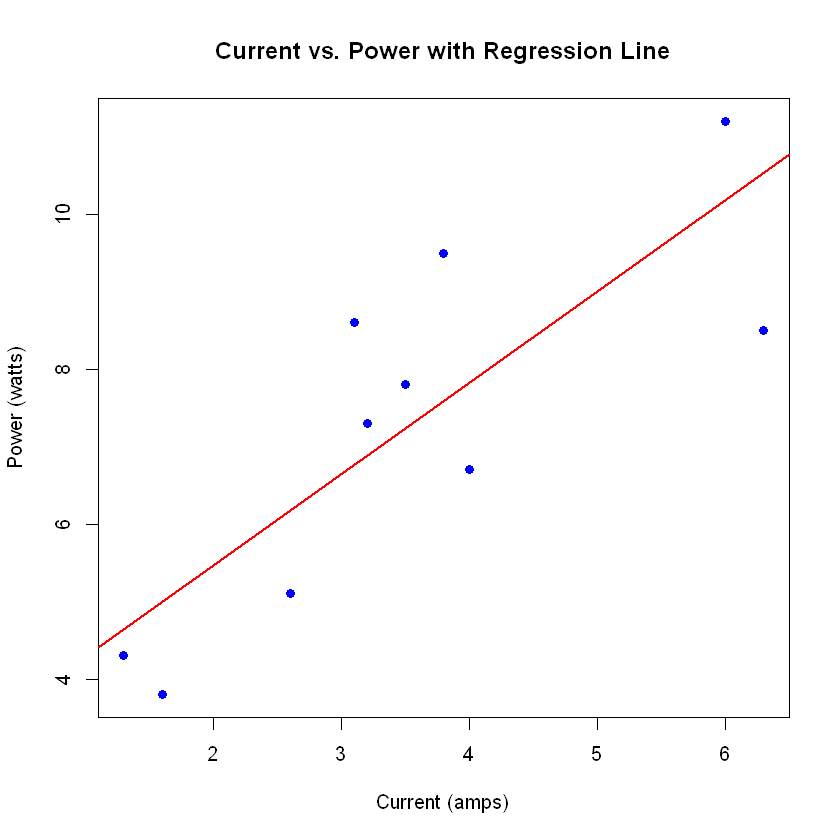

In [66]:
# 8. Create a scatter plot with the regression line
plot(x, y,
     main = "Current vs. Power with Regression Line",
     xlab = "Current (amps)",
     ylab = "Power (watts)",
     pch = 19, col = "blue")
abline(linear_model, col = "red", lwd = 2)

<b> Observations: </b>

Answer: Yes, there is sufficient evidence to conclude that a significant linear relationship exists between the current and the power delivered at a 95% confidence level.

#### Findings:

The analysis of the electrical circuit data reveals a strong, positive linear relationship between current and power.

1. Correlation: The correlation coefficient (r) is 0.816, indicating a strong positive linear relationship. This is visually confirmed by the scatter plot, where the data points generally trend upward and are clustered closely around the regression line.

2. Regression Equation: The line of best fit is y^ = 3.11 + 1.18 x. This equation shows that for every 1-amp increase in current, the effective power delivered is estimated to increase by approximately 1.18 watts.

3. Hypothesis Test: The statistical evidence is conclusive. The p-value for the slope is 0.00399, which is significantly less than the 5% significance level (α = 0.05). This leads us to reject the null hypothesis and conclude that the relationship is statistically significant.

4. Model Fit and Prediction: The coefficient of determination (R2) is 0.6659, meaning that approximately 66.6% of the variability in the power delivered can be explained by the linear relationship with the current. 

This demonstrates that the model is a reasonably good fit for the data. Using this model, the best estimate for the power delivered at a current of 5.00 A is 9.00 watts. The standard error of the estimate, 1.443 watts, tells us the average distance of the observed data points from our regression line.

In [67]:
# Clear the console and set options for a clean start
rm(list = ls())
options(scipen = 999) # Disable scientific notation for readability

### No. 2
The British Department of Transportation studied to see if people avoid driving or shopping, or have more accidents on Friday the 13th. They collected data from different locations (Friday the 13th, 2019). The data for each location on the two different dates is in the table: 

Traffic <- read.csv("https://krkozak.github.io/MAT160/traffic.csv")

1. Determine the correlation coefficient between the data from the two dates (X6th and X13th).
2. Find and state the equation of the linear regression line.
3. Calculate the coefficient of determination
4. Determine if there is sufficient evidence to conclude that there is a significant linear relationship between X6th and X13th data

In [68]:
# Problem: Friday the 13th Traffic Data
# Step 1. Load and read the data from the provided URL
traffic <- read.csv("https://krkozak.github.io/MAT160/traffic.csv")
head(traffic)

,source,year,month,X6th,X13th,location
,<chr>,<chr>,<chr>,<int>,<int>,<chr>
1,traffic,"1990,",July,139246,138548,7 to 8
2,traffic,"1990,",July,134012,132908,9 to 10
3,traffic,"1991,",September,137055,136018,7 to 8
4,traffic,"1991,",September,133732,131843,9 to 10
5,traffic,"1991,",December,123552,121641,7 to 8
6,traffic,"1991,",December,121139,118723,9 to 10


In [69]:
str(traffic) # Exploring the dataframe information

'data.frame':	61 obs. of  6 variables:
 $ source  : chr  "traffic" "traffic" "traffic" "traffic" ...
 $ year    : chr  "1990," "1990," "1991," "1991," ...
 $ month   : chr  "July" "July" "September" "September" ...
 $ X6th    : int  139246 134012 137055 133732 123552 121139 128293 124631 124609 117584 ...
 $ X13th   : int  138548 132908 136018 131843 121641 118723 125532 120249 122770 117263 ...
 $ location: chr  "7 to 8" "9 to 10" "7 to 8" "9 to 10" ...


In [70]:
summary(traffic) # Exploring the dataframe descriptive statistics

    source              year              month                X6th       
 Length:61          Length:61          Length:61          Min.   :     3  
 Class :character   Class :character   Class :character   1st Qu.:  3799  
 Mode  :character   Mode  :character   Mode  :character   Median :  4942  
                                                          Mean   : 24714  
                                                          3rd Qu.:  6568  
                                                          Max.   :139246  
     X13th          location        
 Min.   :     4   Length:61         
 1st Qu.:  3848   Class :character  
 Median :  4882   Mode  :character  
 Mean   : 24448                     
 3rd Qu.:  6648                     
 Max.   :138548                     

In [71]:
# 2. Determine the correlation coefficient between X6th and X13th
# The cor() function calculates the correlation coefficient (r)
correlation_coefficient <- cor(traffic$X6th, traffic$X13th)

# Calculate the coefficient of determination (R^2)
r_squared <- correlation_coefficient^2
r_squared_percent <- r_squared * 100

cat("--- Correlation Coefficient (r) ---\n")
cat("r =", correlation_coefficient, "\n")
cat("This indicates a very strong positive linear relationship between the activity counts on the 6th and the 13th.\n")
cat("\n")

cat("--- Coefficient of Determination (R^2) ---\n")
cat("R^2 =", r_squared, "\n")
cat("This means that approximately", round(r_squared_percent, 2), "% of the variability in the traffic count on the 13th can be explained by the linear relationship with the traffic count on the 6th.\n\n")

--- Correlation Coefficient (r) ---
r = 0.9999418 
This indicates a very strong positive linear relationship between the activity counts on the 6th and the 13th.

--- Coefficient of Determination (R^2) ---
R^2 = 0.9998835 
This means that approximately 99.99 % of the variability in the traffic count on the 13th can be explained by the linear relationship with the traffic count on the 6th.



In [72]:
# 3. Find the equation of the linear regression line
# We use lm() to fit the linear model, with X13th as the dependent variable (y)
# and X6th as the independent variable (x).
linear_model <- lm(traffic$X13th ~ traffic$X6th)

# Print the model summary to get all key metrics
cat("--- Linear Regression Model Summary ---\n")
model_summary <- summary(linear_model)
print(model_summary)
cat("\n")

--- Linear Regression Model Summary ---

Call:
lm(formula = traffic$X13th ~ traffic$X6th)

Residuals:
    Min      1Q  Median      3Q     Max 
-2627.7  -100.7   -28.2   116.2  1328.4 

Coefficients:
               Estimate Std. Error t value            Pr(>|t|)    
(Intercept)  101.724789  72.316341   1.407               0.165    
traffic$X6th   0.985108   0.001384 711.631 <0.0000000000000002 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 497.6 on 59 degrees of freedom
Multiple R-squared:  0.9999,	Adjusted R-squared:  0.9999 
F-statistic: 5.064e+05 on 1 and 59 DF,  p-value: < 0.00000000000000022




In [73]:
# Extract and state the regression equation
b0 <- coef(linear_model)[1]
b1 <- coef(linear_model)[2]
cat("Equation of the linear regression line: y_hat =", round(b0, 2), "+", round(b1, 2), "x\n\n")

Equation of the linear regression line: y_hat = 101.72 + 0.99 x



In [74]:
# 5. Determine if there is a significant linear relationship
# This is done by testing the null hypothesis that the slope is zero.
# The p-value for the slope is extracted from the model summary.
alpha <- 0.05
p_value_slope <- model_summary$coefficients["traffic$X6th", "Pr(>|t|)"]

cat("--- Hypothesis Test for Significance ---\n")
cat("H0: The slope is zero (no linear relationship)\n")
cat("Ha: The slope is not zero (a significant linear relationship exists)\n")
cat("P-value for the slope:", p_value_slope, "\n")
if (p_value_slope < alpha) {
  cat("Decision: Since the p-value (", p_value_slope, ") is less than alpha (", alpha, "), we reject the null hypothesis.\n")
  cat("Conclusion: There is sufficient evidence to conclude that there is a significant linear relationship between the data.\n")
} else {
  cat("Decision: Since the p-value (", p_value_slope, ") is not less than alpha (", alpha, "), we fail to reject the null hypothesis.\n")
  cat("Conclusion: There is not sufficient evidence to conclude that there is a significant linear relationship between the data.\n")
}

--- Hypothesis Test for Significance ---
H0: The slope is zero (no linear relationship)
Ha: The slope is not zero (a significant linear relationship exists)
P-value for the slope: 0.0000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000009338726 
Decision: Since the p-value ( 0.0000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000009338726 ) is less than alpha ( 0.05 ), we reject the null hypothesis.
Conclusion: There is sufficient evidence to conclude that there is a significant linear relationship between the data.


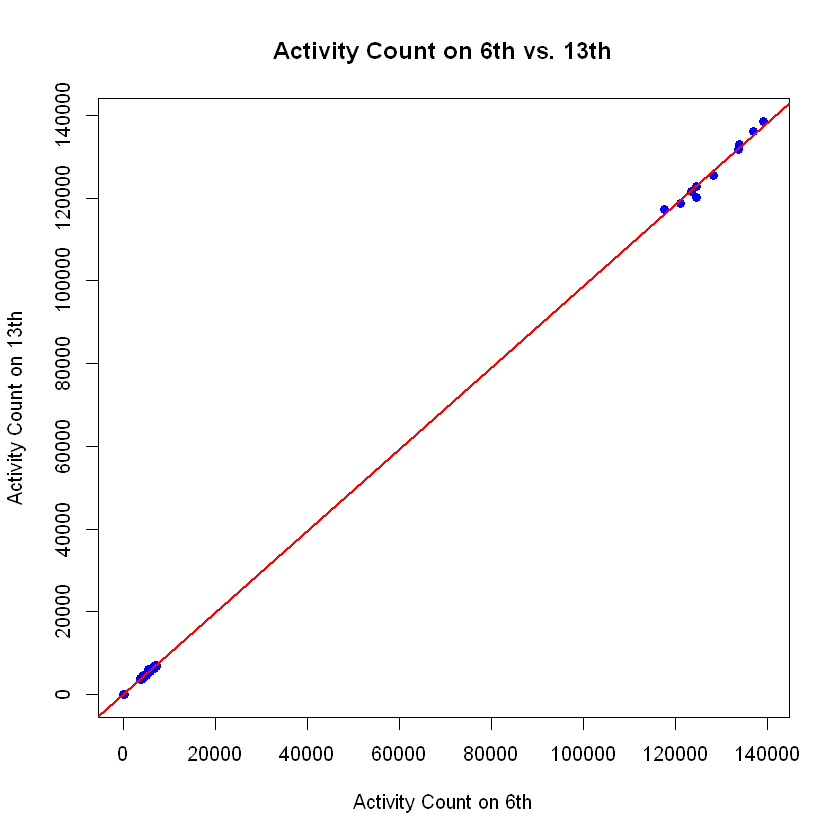

In [75]:
# 6. Visualize the data and the regression line
plot(traffic$X6th, traffic$X13th,
      main = "Activity Count on 6th vs. 13th",
      xlab = "Activity Count on 6th",
      ylab = "Activity Count on 13th",
      pch = 19, col = "blue")
 abline(linear_model, col = "red", lwd = 2)

<b> Observations: </b>

Answer: Yes, there is overwhelming evidence at the 5% significance level to conclude that there is a significant linear relationship between the activity counts on the 6th and the 13th.

Claim: The claim is that a significant linear relationship exists between the activity counts on the 6th and 13th.

Decision: Based on our p-value being virtually zero (p < 2.2 × 10−16) and significantly less than our significance level of α = 0.05, we reject the null hypothesis (H0​:β1 = 0). This decision supports the claim.

This strong statistical conclusion is reinforced by the following parameters:

1. Correlation Coefficient (r): The correlation coefficient is r ≈ 0.9999. This indicates an almost perfect, positive linear relationship. The data points on the scatter plot are extremely close to the regression line, showing that as the activity count on the 6th of the month increases, the count on the 13th also increases with a near-identical magnitude.

2. Coefficient of Determination (R2): The coefficient of determination is R2 ≈ 0.9999. This is an exceptionally high value, meaning that an impressive 99.99% of the variability in the traffic count on the 13th is explained by the linear relationship with the traffic count on the 6th.

3. Linear Regression Equation: The equation of the line of best fit is y^ = 101.72 + 0.99x. The slope (b1 ≈ 0.99) reinforces the one-to-one relationship between the two dates, suggesting that the day of the week has a negligible impact on overall traffic volume.

4. Hypothesis Test Statistics: The evidence is robust. The calculated t-statistic for the slope is a very high value of 711.631 with 59 degrees of freedom, leading to the extremely small p-value that supports our conclusion.

In [76]:
# End